# BioVision-Path
## Biomedical Cell Nuclei Segmentation using U-Net

### OBJECTIVE
This notebook implements an end-to-end semantic segmentation pipeline using a custom U-Net trained from scratch.
We will:
1. Verify, download, and extract the Triple Negative Breast Cancer (TNBC) Nuclei Segmentation dataset from Zenodo.
2. Construct a custom lightweight U-Net architecture with skip connections.
3. Preprocess and apply synchronized joint geometric transforms to slide images and corresponding binary masks.
4. Train and evaluate the model using Dice coefficient, Jaccard/IoU, and pixel accuracy.

### 1. Setup & Environment

In [1]:
# Environment Report & CUDA Detection
import sys
import torch
import torchvision
from src.reproducibility import print_environment_report, set_seed
from src.config import CONFIG

# Print report
env = print_environment_report()
set_seed(CONFIG["seed"])


                    ENVIRONMENT REPORT                    
Python Version    : 3.10.9
PyTorch Version   : 2.13.0+cpu
CUDA Available    : False
GPU Name          : None (CPU Fallback)
[Notice] CUDA is not available. System is running in CPU fallback mode.
         In GPU environments (like Colab GPU runtime), this will significantly slow training.
         Please check runtime settings if a GPU was expected.
[Reproducibility] Random seed set to: 42


### 2. Dataset Downloading & Verification

In [2]:
# Download and verify TNBC from Zenodo
from src.segmentation import download_and_extract_tnbc, get_tnbc_dataloaders
import os

tnbc_path = download_and_extract_tnbc(CONFIG["segmentation"]["dataset_url"], CONFIG["data_dir"])
print(f"Dataset files verified in: {tnbc_path}")


[Dataset] TNBC dataset already exists at: data\TNBC_NucleiSegmentation
Dataset files verified in: data\TNBC_NucleiSegmentation


In [3]:
# Set up loaders
train_loader, val_loader, test_loader = get_tnbc_dataloaders(
    dataset_dir=tnbc_path,
    batch_size=CONFIG["segmentation"]["demo"]["batch_size"] if CONFIG["demo_mode"] else CONFIG["segmentation"]["full"]["batch_size"],
    image_size=CONFIG["segmentation"]["image_size"],
    demo_mode=CONFIG["demo_mode"],
    subset_size=CONFIG["segmentation"]["demo"]["subset_size"]
)

# Run Image-Mask pairing validation on first batch
images, masks = next(iter(train_loader))
print(f"Batch images shape: {images.shape} (Expected: [B, 3, 256, 256])")
print(f"Batch masks shape : {masks.shape} (Expected: [B, 1, 256, 256])")
assert images.shape[0] == masks.shape[0], "Batch dimension mismatch!"
assert masks.max() <= 1.0 and masks.min() >= 0.0, "Mask should be binary [0, 1]!"


[Dataset] Found 50 image-mask pairs in TNBC dataset.
[Dataset] Found 50 image-mask pairs in TNBC dataset.
[Dataset] DEMO MODE: Subsetting TNBC dataset. Train: 8, Val: 2, Test: 2
Batch images shape: torch.Size([4, 3, 256, 256]) (Expected: [B, 3, 256, 256])
Batch masks shape : torch.Size([4, 1, 256, 256]) (Expected: [B, 1, 256, 256])


### 3. U-Net Model & Training

In [4]:
# Instantiate custom U-Net and train
from src.models import UNet
from src.training import fit_model
import torch.nn as nn
import torch.optim as optim

unet_model = UNet(in_channels=3, out_channels=1).to(CONFIG["device"])
optimizer = optim.AdamW(unet_model.parameters(), lr=CONFIG["segmentation"]["demo"]["lr"])
# BCE + Dice loss is ideal for binary segmentation with small foreground targets (nuclei)
criterion = nn.BCEWithLogitsLoss()

unet_history = fit_model(
    model=unet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=CONFIG["segmentation"]["demo"]["epochs"] if CONFIG["demo_mode"] else CONFIG["segmentation"]["full"]["epochs"],
    device=CONFIG["device"],
    checkpoint_path="checkpoints/unet_segmentation.pth",
    task_type="segmentation"
)


[Training] Starting training on device: cpu (Task: segmentation)


Training Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Training Batches:  50%|█████     | 1/2 [00:02<00:02,  2.35s/it]

Training Batches: 100%|██████████| 2/2 [00:04<00:00,  2.36s/it]

Validation Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Validation Batches: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]

Epoch 1/1 | Train Loss: 0.6553 | Train Acc: 0.0000 | Val Loss: 0.7011 | Val Acc: 0.0000 | Time: 5.2s
 => State saved! New best loss: 0.7011
[Training] Restoring best checkpoint from: checkpoints/unet_segmentation.pth


### 4. Quantitative & Qualitative Evaluation

In [5]:
# Evaluate on test set
from src.evaluation import evaluate_segmentation
from src.visualization import plot_segmentation_predictions

seg_metrics = evaluate_segmentation(unet_model, test_loader, CONFIG["device"])
print("--- U-Net Test Segmentation Metrics ---")
for k, v in seg_metrics.items():
    print(f"{k:20s}: {v:.4f}")


--- U-Net Test Segmentation Metrics ---
mean_dice           : 0.2266
mean_iou            : 0.1384
pixel_accuracy      : 0.1384


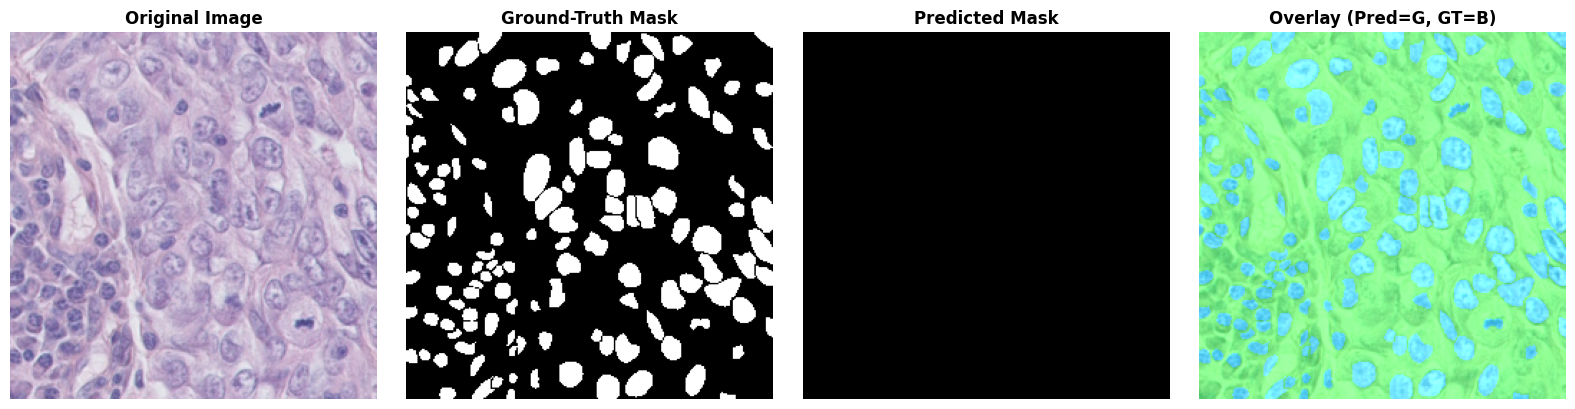

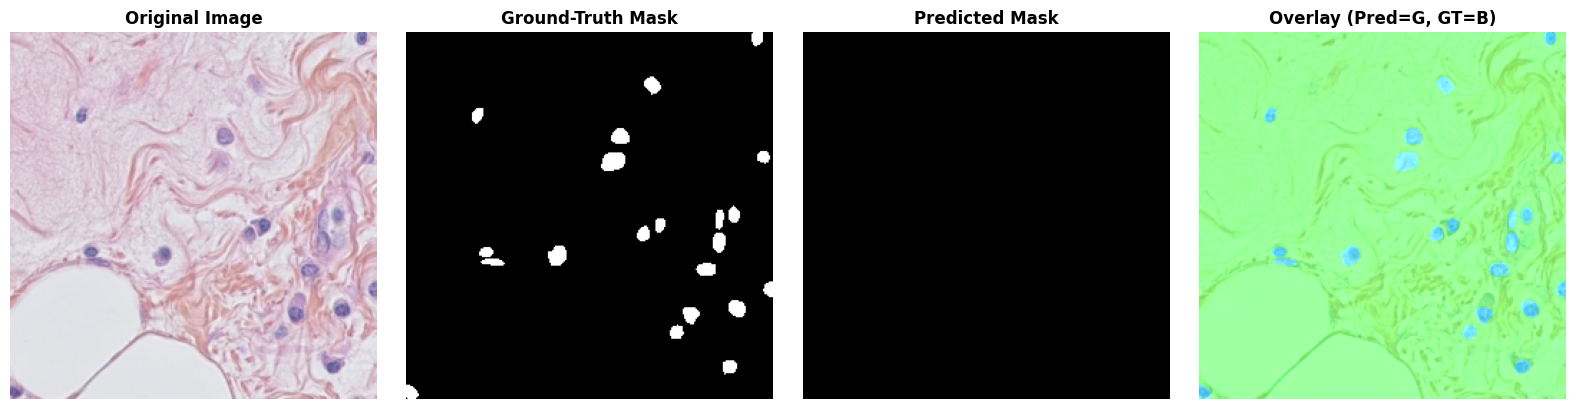

In [6]:
# Visualize prediction overlay examples
images_test, masks_test = next(iter(test_loader))
unet_model.eval()
with torch.no_grad():
    preds_test = torch.sigmoid(unet_model(images_test.to(CONFIG["device"])))
    preds_mask = (preds_test > 0.5).float()

# Plot first 2 examples
plot_segmentation_predictions(images_test[0], masks_test[0], preds_mask[0], save_path="outputs/segmentation/sample_predictions_1.png")
plot_segmentation_predictions(images_test[1], masks_test[1], preds_mask[1], save_path="outputs/segmentation/sample_predictions_2.png")


### 5. Responsible Use & Limitations
- **educational/research purpose**: This notebook segments glioblastoma and mammary nuclei and is not medically validated.
- **boundary errors**: U-Net models can merge touching nuclei or miss small ones due to noise, scanner variability, or resolution limitations.
- **no diagnostic claim**: Predicted segmentation masks represent visual spatial distributions and should not be used as direct clinical biomarkers.